<a href="https://colab.research.google.com/github/iperezv-cpu/ML/blob/main/Homework_1_ML_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem 1**

In [1695]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Read Data**

In [1696]:
#input dara link
url = 'https://raw.githubusercontent.com/iperezv-cpu/ML/refs/heads/main/D3.csv'


df = pd.read_csv(url)

# Display the first 10 rows of the DataFrame
print(df.head(10))

         X1        X2        X3         Y
0  0.000000  3.440000  0.440000  4.387545
1  0.040404  0.134949  0.888485  2.679650
2  0.080808  0.829899  1.336970  2.968490
3  0.121212  1.524848  1.785455  3.254065
4  0.161616  2.219798  2.233939  3.536375
5  0.202020  2.914747  2.682424  3.815420
6  0.242424  3.609697  3.130909  4.091200
7  0.282828  0.304646  3.579394  2.363715
8  0.323232  0.999596  0.027879  3.832965
9  0.363636  1.694545  0.476364  4.098950


**Labels and parts of Data**

In [1697]:
# Separate features and labels
X1 = df.values[:, 0]  # get input values from first column -- X1 is a list here
X2 = df.values[:, 1]  # get output values from second column -- X2 is the list here
X3 = df.values[:, 2]  # get output values from second column -- X3 is the list here

Y = df.values[:, 3]  # get output values from second column -- Y is the list here


m1 = len(X1)  # Number of training examples
m2 = len(X2)  # Number of training examples
m3 = len(X3)  # Number of training examples


n = len(Y)  # Number of training examples


# Display first 5 records and the total number of training examples
print('X1 = ', X1[: 5])
print('X2 = ', X2[: 5])
print('X3 = ', X3[: 5])


print('y = ', Y[: 5])

print('m1 = ', m1)
print('m2 = ', m2)
print('m3 = ', m3)

print('n = ', n)



X1 =  [0.         0.04040404 0.08080808 0.12121212 0.16161616]
X2 =  [3.44       0.1349495  0.82989899 1.52484848 2.21979798]
X3 =  [0.44       0.88848485 1.3369697  1.78545454 2.23393939]
y =  [4.38754501 2.6796499  2.96848981 3.25406475 3.53637472]
m1 =  100
m2 =  100
m3 =  100
n =  100


**Plot for X1-Y**

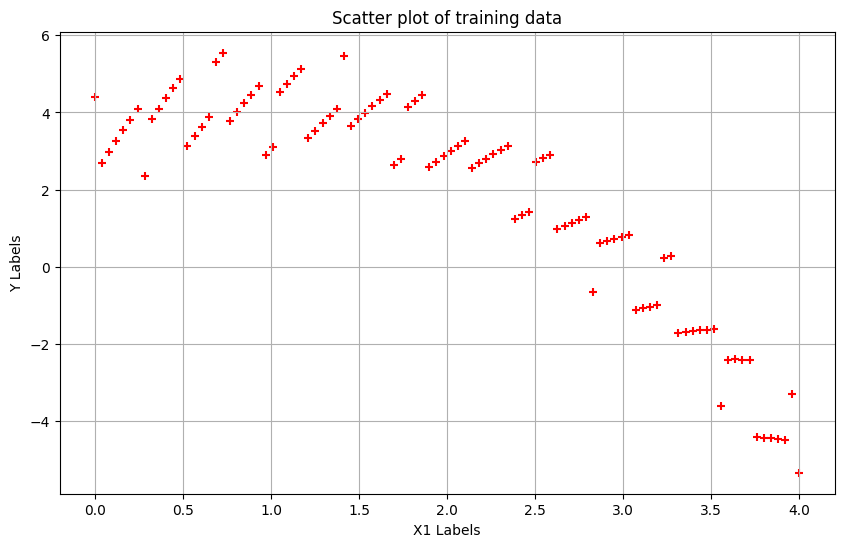

In [1698]:
X1 = df.values[:, 0]  # get input values from the first column -- X is a list here which is a 1 dimentional array
Y = df.values[:, 3]  # get output values from the second column --  Y is a list here which is a 2 dimentional array

# Scatter plot
plt.scatter(X1, Y, color='red', marker='+')

# Grid, labels, and title
plt.grid(True)
plt.rcParams["figure.figsize"] = (6, 6)
plt.xlabel('X1 Labels')
plt.ylabel('Y Labels')
plt.title('Scatter plot of training data')

# Show the plot
plt.show()

**Steps for linear Regression on x1-Y**

**Step 1**

In [1699]:
X_0 = np.ones((m1, 1))
X_0[:5]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.]])

**Step 2**

In [1700]:
X_1 = X1.reshape(m1, 1)
X_1[:10]

array([[0.        ],
       [0.04040404],
       [0.08080808],
       [0.12121212],
       [0.16161616],
       [0.2020202 ],
       [0.24242424],
       [0.28282828],
       [0.32323232],
       [0.36363636]])

**Step 3**

In [1701]:
# Lets use hstack() function from numpy to stack X_0 and X_1 horizontally (i.e. column
# This will be our final X matrix (feature matrix)
X1 = np.hstack((X_0, X_1))
X1[:5]

array([[1.        , 0.        ],
       [1.        , 0.04040404],
       [1.        , 0.08080808],
       [1.        , 0.12121212],
       [1.        , 0.16161616]])

In [1702]:
theta = np.zeros(2)
theta

array([0., 0.])

**Computing Cost**

**For X1:**

In [1703]:
def compute_cost(X1, Y, theta):
    """
    Compute cost for linear regression.

    Parameters:
    X : 2D array where each row represents the training example and each column represent the feature
        m = number of training examples
        n = number of features (including X_0 column of ones)
    y : 1D array of labels/target values for each training example. dimension(m)
    theta : 1D array of fitting parameters or weights. Dimension (n)

    Returns:
    J : Scalar value, the cost
    """
    predictions = X1.dot(theta)
    errors = np.subtract(predictions, Y)            ## Prediction -Y
    sqrErrors = np.square(errors)                   ##Squares(Error)
    J = 1 / (2 * m1) * np.sum(sqrErrors)            ##Average cost: Sumof Squared errors
    return J

**Cost of Theta**

In [1704]:
# Lets compute the cost for theta values
cost = compute_cost(X1, Y, theta)
print('The cost for given values of theta_0 and theta_1 =', cost)

The cost for given values of theta_0 and theta_1 = 5.524438459196242


**Gradient Descent**

In [1705]:
def gradient_descent(X1, Y, theta, alpha, iterations):
    """
    Compute the optimal parameters using gradient descent for linear regression.

    Parameters:
    X : 2D array where each row represents the training example and each column represents the feature
        m = number of training examples
        n = number of features (including X_0 column of ones)

    y : 1D array of labels/target values for each training example. dimension(m)
    theta : 1D array of fitting parameters or weights. Dimension (n)
    alpha : Learning rate (scalar)
    iterations : Number of iterations (scalar)

    Returns:
    theta : Updated values of fitting parameters or weights after 'iterations' iterations. Dimension (n)
    cost_history : Array containing the cost for each iteration. Dimension (iterations)
    """

    m1 = len(Y)  # Number of training examples
    cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = X1.dot(theta)
        errors = np.subtract(predictions, Y)
        sum_delta = (alpha / m1) * X1.transpose().dot(errors)
        theta -= sum_delta
        cost_history[i] = compute_cost(X1, Y, theta)

    return theta, cost_history

In [1706]:
theta = [0., 0.]
iterations = 1500
alpha = 0.01

In [1707]:
theta, cost_history = gradient_descent(X1, Y, theta, alpha, iterations)
print('Final value of theta =', theta)
print('cost_history =', cost_history)

Final value of theta = [ 5.71850653 -1.9568206 ]
cost_history = [5.48226715 5.44290965 5.40604087 ... 0.99063932 0.99061433 0.99058944]


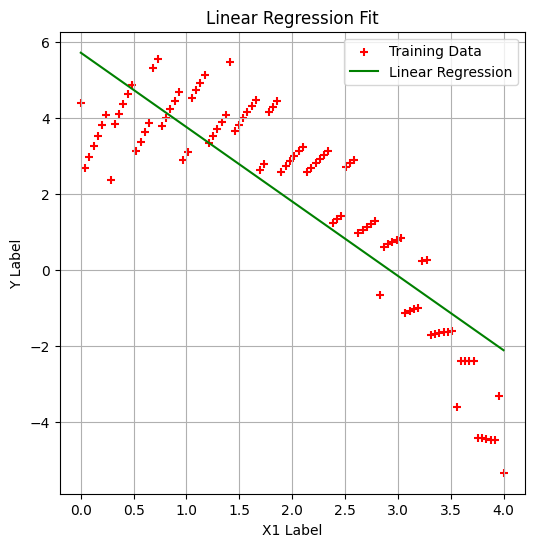

In [1708]:
# Scatter plot for the training data
plt.scatter(X1[:, 1], Y, color='red', marker='+', label='Training Data')

# Line plot for the linear regression model
plt.plot(X1[:, 1], X1.dot(theta), color='green', label='Linear Regression')

# Plot customizations
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('X1 Label')
plt.ylabel('Y Label')
plt.title('Linear Regression Fit')
plt.legend()

# Show the plot
plt.show()


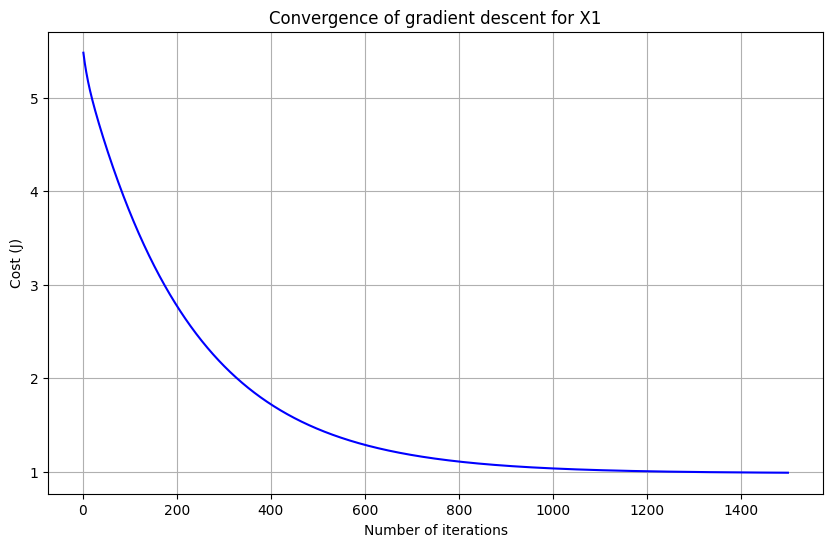

In [1709]:
plt.plot(range(1, iterations + 1), cost_history, color='blue')
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)

plt.xlabel('Number of iterations')
plt.ylabel('Cost (J)')
plt.title('Convergence of gradient descent for X1')

# Show the plot
plt.show()

**Data for X2:**

**Plot for X2-Y**

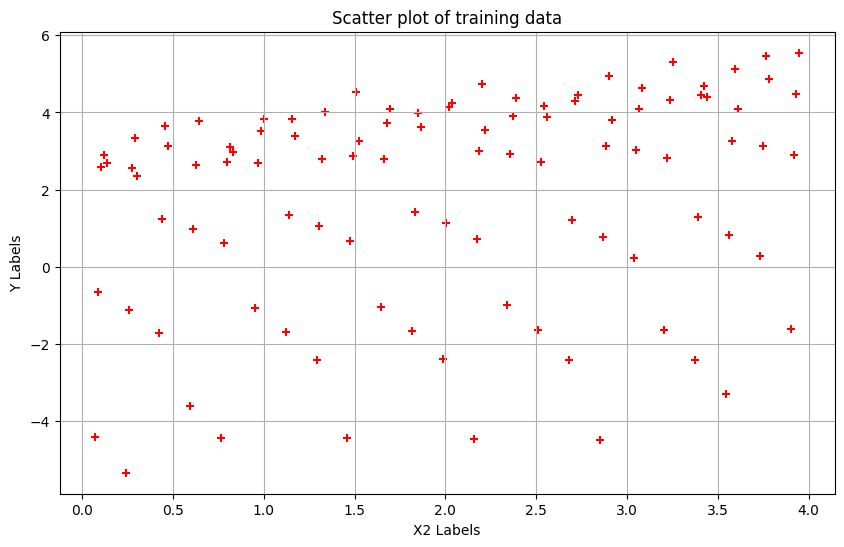

In [1710]:
X2 = df.values[:, 1]  # get input values from the first column -- X is a list here which is a 1 dimentional array
Y = df.values[:, 3]  # get output values from the second column --  Y is a list here which is a 2 dimentional array

# Scatter plot
plt.scatter(X2, Y, color='red', marker='+')

# Grid, labels, and title
plt.grid(True)
plt.rcParams["figure.figsize"] = (6, 6)
plt.xlabel('X2 Labels')
plt.ylabel('Y Labels')
plt.title('Scatter plot of training data')

# Show the plot
plt.show()

**Step 1**

In [1711]:
X_0 = np.ones((m2, 1))
X_0[:5]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.]])

**Step 2**

In [1712]:
X_1 = X2.reshape(m2, 1)
X_1[:10]

array([[3.44      ],
       [0.1349495 ],
       [0.82989899],
       [1.52484848],
       [2.21979798],
       [2.91474747],
       [3.60969697],
       [0.30464646],
       [0.99959596],
       [1.69454546]])

**Step3**

In [1713]:
# Lets use hstack() function from numpy to stack X_0 and X_1 horizontally (i.e. column
# This will be our final X matrix (feature matrix)
X2 = np.hstack((X_0, X_1))
X2[:5]

array([[1.        , 3.44      ],
       [1.        , 0.1349495 ],
       [1.        , 0.82989899],
       [1.        , 1.52484848],
       [1.        , 2.21979798]])

In [1714]:
theta = np.zeros(2)
theta

array([0., 0.])

***Computing Cost for X2**

In [1715]:
def compute_cost(X2, Y, theta):
    """
    Compute cost for linear regression.

    Parameters:
    X : 2D array where each row represents the training example and each column represent the feature
        m = number of training examples
        n = number of features (including X_0 column of ones)
    y : 1D array of labels/target values for each training example. dimension(m)
    theta : 1D array of fitting parameters or weights. Dimension (n)

    Returns:
    J : Scalar value, the cost
    """
    predictions = X2.dot(theta)
    errors = np.subtract(predictions, Y)
    sqrErrors = np.square(errors)
    J = 1 / (2 * m2) * np.sum(sqrErrors)
    return J

**Cost of Theta**

In [1716]:
# Lets compute the cost for theta values
cost = compute_cost(X2, Y, theta)
print('The cost for given values of theta_0 and theta_1 =', cost)

The cost for given values of theta_0 and theta_1 = 5.524438459196242


**Gradient Descent**

In [1717]:
def gradient_descent(X2, Y, theta, alpha, iterations):
    """
    Compute the optimal parameters using gradient descent for linear regression.

    Parameters:
    X : 2D array where each row represents the training example and each column represents the feature
        m = number of training examples
        n = number of features (including X_0 column of ones)
    y : 1D array of labels/target values for each training example. dimension(m)
    theta : 1D array of fitting parameters or weights. Dimension (n)
    alpha : Learning rate (scalar)
    iterations : Number of iterations (scalar)

    Returns:
    theta : Updated values of fitting parameters or weights after 'iterations' iterations. Dimension (n)
    cost_history : Array containing the cost for each iteration. Dimension (iterations)
    """

    m2 = len(Y)  # Number of training examples
    cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = X2.dot(theta)
        errors = np.subtract(predictions, Y)
        sum_delta = (alpha / m2) * X2.transpose().dot(errors)
        theta -= sum_delta
        cost_history[i] = compute_cost(X2, Y, theta)

    return theta, cost_history

In [1718]:
theta = [0., 0.]
iterations = 1500
alpha = 0.01

In [1719]:
theta, cost_history = gradient_descent(X2, Y, theta, alpha, iterations)
print('Final value of theta =', theta)
print('cost_history =', cost_history)

Final value of theta = [0.71988473 0.56390334]
cost_history = [5.29831663 5.09909109 4.92356115 ... 3.5993997  3.59939955 3.5993994 ]


**Plot for X2-y**

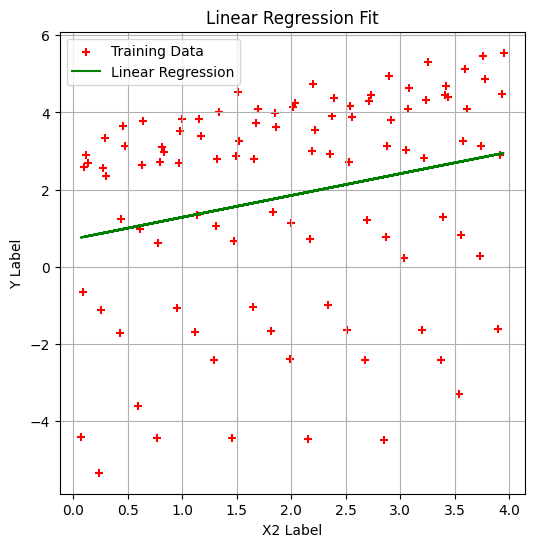

In [1720]:
# Scatter plot for the training data
plt.scatter(X2[:, 1], Y, color='red', marker='+', label='Training Data')

# Line plot for the linear regression model
plt.plot(X2[:, 1], X2.dot(theta), color='green', label='Linear Regression')

# Plot customizations
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('X2 Label')
plt.ylabel('Y Label')
plt.title('Linear Regression Fit')
plt.legend()

# Show the plot
plt.show()

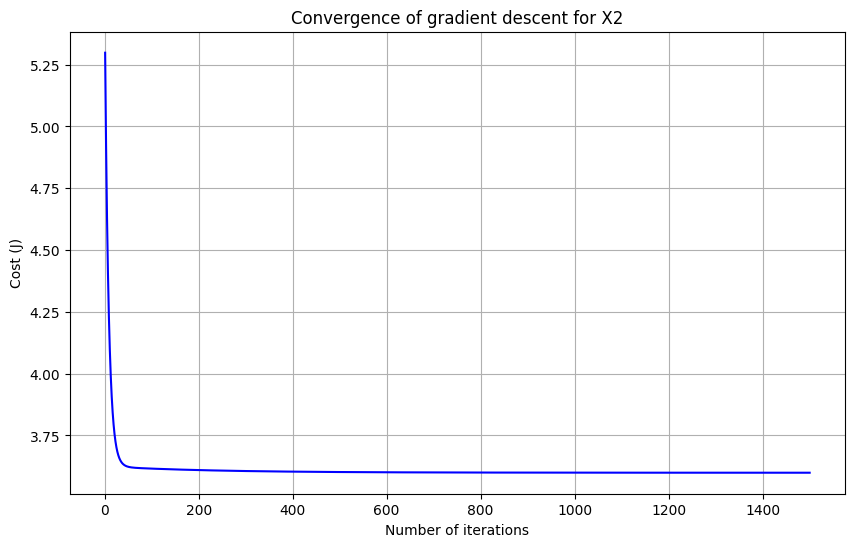

In [1721]:
plt.plot(range(1, iterations + 1), cost_history, color='blue')
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)

plt.xlabel('Number of iterations')
plt.ylabel('Cost (J)')
plt.title('Convergence of gradient descent for X2')

# Show the plot
plt.show()

**Data for X3**

**Plot for X3-Y**

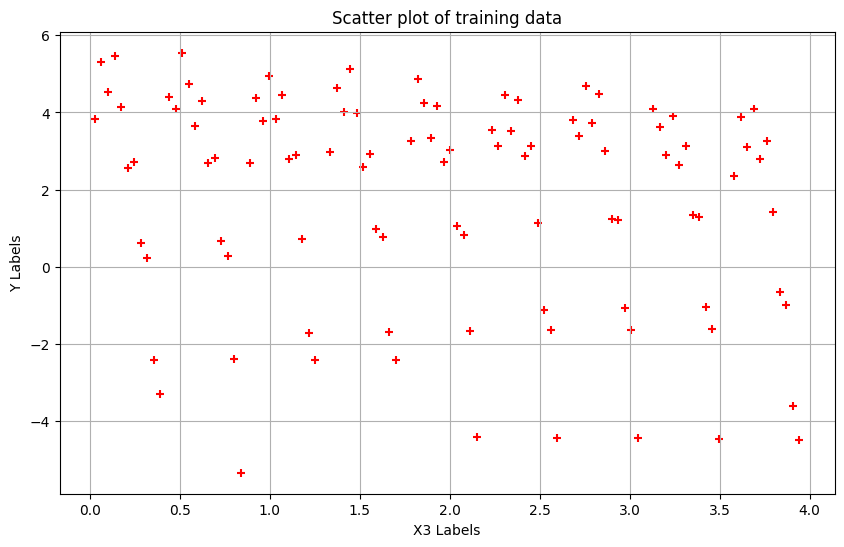

In [1722]:
X3 = df.values[:, 2]  # get input values from the first column -- X is a list here which is a 1 dimentional array
Y = df.values[:, 3]  # get output values from the second column --  Y is a list here which is a 2 dimentional array

# Scatter plot
plt.scatter(X3, Y, color='red', marker='+')

# Grid, labels, and title
plt.grid(True)
plt.rcParams["figure.figsize"] = (6, 6)
plt.xlabel('X3 Labels')
plt.ylabel('Y Labels')
plt.title('Scatter plot of training data')

# Show the plot
plt.show()

**Step 1**

In [1723]:
X_0 = np.ones((m3, 1))
X_0[:5]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.]])

**Step 2**

In [1724]:
X_1 = X3.reshape(m3, 1)
X_1[:10]

array([[0.44      ],
       [0.88848485],
       [1.3369697 ],
       [1.78545454],
       [2.23393939],
       [2.68242424],
       [3.13090909],
       [3.57939394],
       [0.02787879],
       [0.47636364]])

**Step 3**

In [1725]:
# Lets use hstack() function from numpy to stack X_0 and X_1 horizontally (i.e. column
# This will be our final X matrix (feature matrix)
X3 = np.hstack((X_0, X_1))
X3[:5]

array([[1.        , 0.44      ],
       [1.        , 0.88848485],
       [1.        , 1.3369697 ],
       [1.        , 1.78545454],
       [1.        , 2.23393939]])

In [1726]:
theta = np.zeros(2)
theta

array([0., 0.])

**Computing Cost**

In [1727]:
def compute_cost(X3, Y, theta):
    """
    Compute cost for linear regression.

    Parameters:
    X : 2D array where each row represents the training example and each column represent the feature
        m = number of training examples
        n = number of features (including X_0 column of ones)
    y : 1D array of labels/target values for each training example. dimension(m)
    theta : 1D array of fitting parameters or weights. Dimension (n)

    Returns:
    J : Scalar value, the cost
    """
    predictions = X3.dot(theta)
    errors = np.subtract(predictions, Y)
    sqrErrors = np.square(errors)
    J = 1 / (2 * m3) * np.sum(sqrErrors)
    return J

**Computing cost of Theta**

In [1728]:
# Lets compute the cost for theta values
cost = compute_cost(X3, Y, theta)
print('The cost for given values of theta_0 and theta_1 =', cost)

The cost for given values of theta_0 and theta_1 = 5.524438459196242


**Gradient Descent**

In [1729]:
def gradient_descent(X3, Y, theta, alpha, iterations):
    """
    Compute the optimal parameters using gradient descent for linear regression.

    Parameters:
    X : 2D array where each row represents the training example and each column represents the feature
        m = number of training examples
        n = number of features (including X_0 column of ones)
    y : 1D array of labels/target values for each training example. dimension(m)
    theta : 1D array of fitting parameters or weights. Dimension (n)
    alpha : Learning rate (scalar)
    iterations : Number of iterations (scalar)

    Returns:
    theta : Updated values of fitting parameters or weights after 'iterations' iterations. Dimension (n)
    cost_history : Array containing the cost for each iteration. Dimension (iterations)
    """

    m3 = len(Y)  # Number of training examples
    cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = X3.dot(theta)
        errors = np.subtract(predictions, Y)
        sum_delta = (alpha / m3) * X3.transpose().dot(errors)
        theta -= sum_delta
        cost_history[i] = compute_cost(X3, Y, theta)

    return theta, cost_history

In [1730]:
theta = [0., 0.]
iterations = 1500
alpha = 0.1

In [1731]:
theta, cost_history = gradient_descent(X3, Y, theta, alpha, iterations)
print('Final value of theta =', theta)
print('cost_history =', cost_history)

Final value of theta = [ 2.8714221  -0.52048288]
cost_history = [4.66843939 4.49602325 4.43685075 ... 3.62945112 3.62945112 3.62945112]


**Plot for x3-Y**

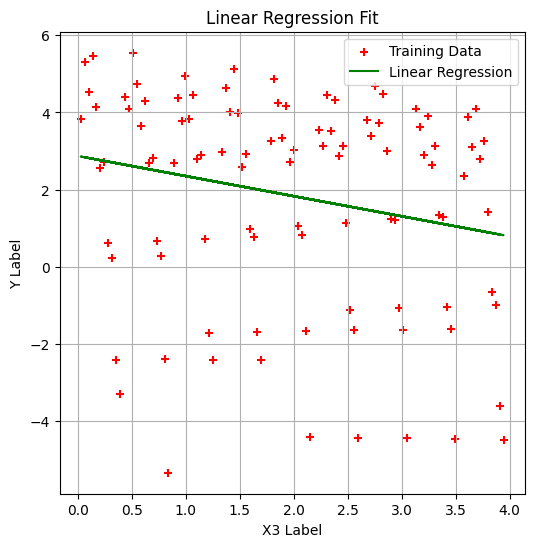

In [1732]:
# Scatter plot for the training data
plt.scatter(X3[:, 1], Y, color='red', marker='+', label='Training Data')

# Line plot for the linear regression model
plt.plot(X3[:, 1], X3.dot(theta), color='green', label='Linear Regression')

# Plot customizations
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('X3 Label')
plt.ylabel('Y Label')
plt.title('Linear Regression Fit')
plt.legend()

# Show the plot
plt.show()

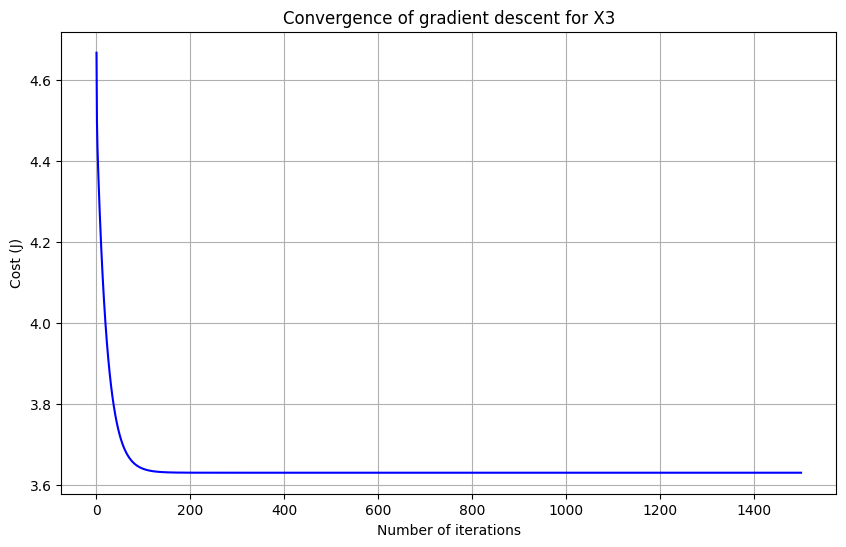

In [1733]:
plt.plot(range(1, iterations + 1), cost_history, color='blue')
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)

plt.xlabel('Number of iterations')
plt.ylabel('Cost (J)')
plt.title('Convergence of gradient descent for X3')

# Show the plot
plt.show()

**Problem 2**

**Combining X1,X2,X3**

In [1734]:
X1 = df.values[:, 0]  # get input values from first column -- X1 is a list here
X2 = df.values[:, 1]  # get output values from second column -- X2 is the list here
X3 = df.values[:, 2]  # get output values from second column -- X3 is the list here

Y = df.values[:, 3]  # get output values from second column -- Y is the list here

m= len(Y)

#colum of zeros for theta

X_0 =np.ones((m,1))

#Reshape columns X1, X2, X3

X_1= X1.reshape(m,1)
X_2= X2.reshape(m,1)
X_3= X3.reshape(m,1)


#combining X's
Xm = np.hstack((X_0, X_1, X_2, X_3))
Xm[:5]



array([[1.        , 0.        , 3.44      , 0.44      ],
       [1.        , 0.04040404, 0.1349495 , 0.88848485],
       [1.        , 0.08080808, 0.82989899, 1.3369697 ],
       [1.        , 0.12121212, 1.52484848, 1.78545454],
       [1.        , 0.16161616, 2.21979798, 2.23393939]])

**Gradient Decsent**

In [1735]:
def gradient_descent(Xm, Y, theta, alpha, iterations):
    """
    Compute the optimal parameters using gradient descent for linear regression.

    Parameters:
    X : 2D array where each row represents the training example and each column represents the feature
        m = number of training examples
        n = number of features (including X_0 column of ones)
    y : 1D array of labels/target values for each training example. dimension(m)
    theta : 1D array of fitting parameters or weights. Dimension (n)
    alpha : Learning rate (scalar)
    iterations : Number of iterations (scalar)

    Returns:
    theta : Updated values of fitting parameters or weights after 'iterations' iterations. Dimension (n)
    cost_history : Array containing the cost for each iteration. Dimension (iterations)
    """

    m3 = len(Y)  # Number of training examples
    cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = Xm.dot(theta)
        errors = np.subtract(predictions, Y)
        sum_delta = (alpha / m3) * Xm.transpose().dot(errors)
        theta -= sum_delta
        cost_history[i] = compute_cost(Xm, Y, theta)

    return theta, cost_history

In [1736]:
theta = [0., 0., 0., 0.]
iterations = 2000
alpha = 0.01

In [1737]:
theta, cost_history = gradient_descent(Xm, Y, theta, alpha, iterations)
print('Final value of theta =', theta)
print('cost_history =', cost_history)

Final value of theta = [ 4.60784132 -1.90393905  0.64927931 -0.16206885]
cost_history = [5.21542243 4.97171977 4.7765543  ... 0.76514569 0.76509252 0.76503946]


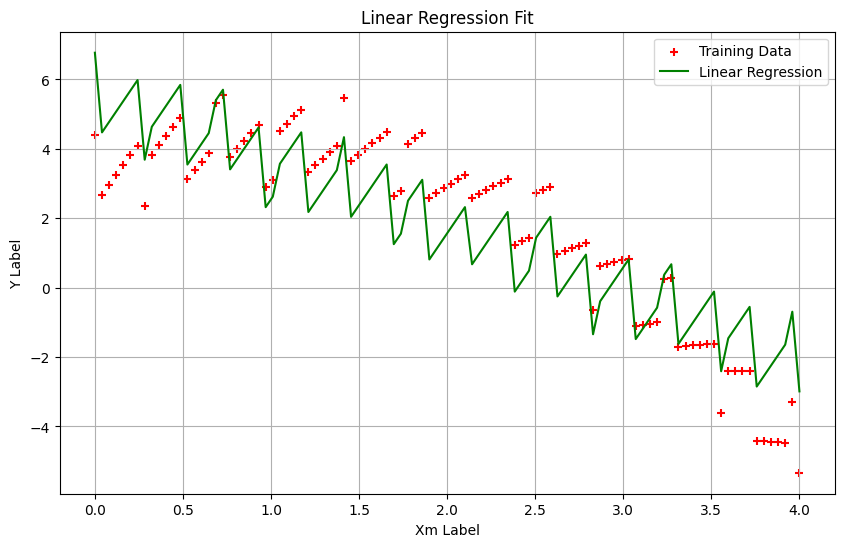

In [1738]:
# Scatter plot for the training data
plt.scatter(Xm[:, 1], Y, color='red', marker='+', label='Training Data')

# Line plot for the linear regression model
plt.plot(Xm[:, 1], Xm.dot(theta), color='green', label='Linear Regression')

# Plot customizations
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('Xm Label')
plt.ylabel('Y Label')
plt.title('Linear Regression Fit')
plt.legend()

# Show the plot
plt.show()

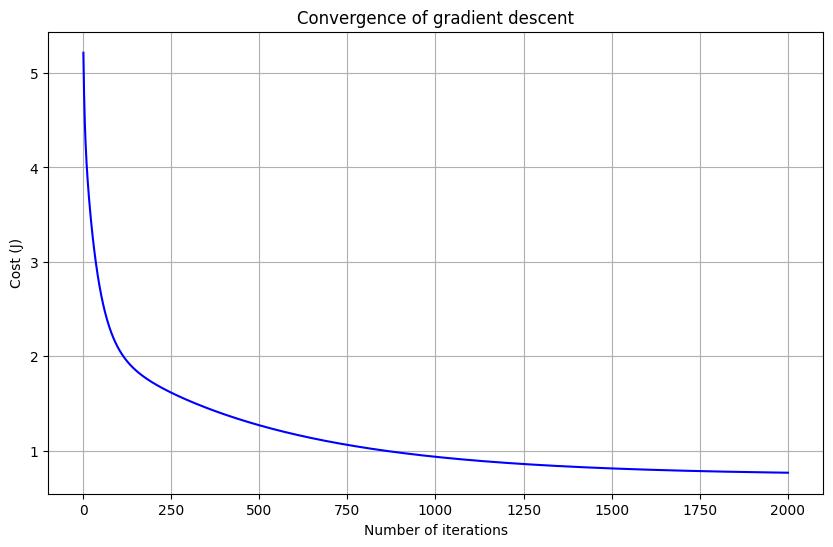

In [1739]:
plt.plot(range(1, iterations + 1), cost_history, color='blue')
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)

plt.xlabel('Number of iterations')
plt.ylabel('Cost (J)')
plt.title('Convergence of gradient descent')

# Show the plot
plt.show()

**Porblem 2.4**

In [1740]:
##Predict Y given: new (X1, X2, X3) values (1, 1, 1), for (2, 0, 4), and for (3, 2, 1)

X1_new = np.array([1, 2, 3])
X2_new = np.array([1, 0, 2])
X3_new = np.array([1, 4, 1])

X0_new = np.ones(3)

X_new = np.column_stack((
    X0_new,
    X1_new,
    X2_new,
    X3_new
))



In [1741]:
predictions = X_new.dot(theta)
New_Y =predictions

**Print out new Y for each X**

In [1742]:
print("Predicted Y for (1, 1, 1):", New_Y[0])
print("Predicted Y for (2, 0, 4):", New_Y[1])
print("Predicted Y for (3, 2, 1):", New_Y[2])

Predicted Y for (1, 1, 1): 3.1911127254543454
Predicted Y for (2, 0, 4): 0.15168781022234334
Predicted Y for (3, 2, 1): 0.03251393005171721
